In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

from qiskit import transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute

df = pd.read_csv('/Users/fabianatorres/Downloads/archive/Malware_and_benign_recognition.csv')
df.head()

,File,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,AddressOfEntryPoint,BaseOfCode,BaseOfData,ImageBase,NumberOfSections,DllCharacteristics,...,MinSectionEntropy,TextSectionSize,DataSectionSize,SuspiciousSectionNames,ImportedDLLs,ImportedFunctions,HasExportTable,ExportedFunctions,OverlaySize,Malicious
0,e_56_clip.exe,28672,24576,0,4864,4096,0,5368709120,7,49504,...,0.015920,24576,4096,0,7,85,0,0,0,0
1,8d9b19c7af036a2a3f6d710fdfb1f45ca1b476f2ad9484...,234496,72704,0,117581,4096,241664,268435456,4,320,...,3.054267,234496,7648,0,3,103,1,1,0,1
2,e0e908a62601140123531aca205c1d54e6a7ec851f09d4...,1024,1536,0,9134,8192,16384,268435456,3,34112,...,0.081539,1024,0,0,1,1,0,0,0,1
3,42438a67636a6981b4e3209449040f6b393f10fe0636df...,48640,75264,0,18028,4096,53248,4194304,5,32832,...,5.441382,48640,9440,0,3,13,0,0,0,1
4,d_233_CastLaunch.dll,73728,49152,0,9040,4096,0,6442450944,8,16736,...,0.015920,69632,4096,0,31,125,1,2,0,0


In [2]:
print(df.shape)
df.info()

(1156, 27)
<class 'pandas.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   File                     1156 non-null   str    
 1   SizeOfCode               1156 non-null   int64  
 2   SizeOfInitializedData    1156 non-null   int64  
 3   SizeOfUninitializedData  1156 non-null   int64  
 4   AddressOfEntryPoint      1156 non-null   int64  
 5   BaseOfCode               1156 non-null   int64  
 6   BaseOfData               1156 non-null   int64  
 7   ImageBase                1156 non-null   uint64 
 8   NumberOfSections         1156 non-null   int64  
 9   DllCharacteristics       1156 non-null   int64  
 10  SizeOfImage              1156 non-null   int64  
 11  SizeOfHeaders            1156 non-null   int64  
 12  Characteristics          1156 non-null   int64  
 13  Subsystem                1156 non-null   int64  
 14  SectionCount            

In [31]:
to_plot = ['SizeOfCode', 'SizeOfInitializedData', 
         'SizeOfUninitializedData', 'AddressOfEntryPoint', 
         'BaseOfData', 'ImageBase', 'NumberOfSections', 
         'DllCharacteristics']

x=df[to_plot]
y=df['Malicious']

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

print(y.head())

x shape: (1156, 8)
y shape: (1156,)
0    0
1    1
2    1
3    1
4    0
Name: Malicious, dtype: int64


In [4]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size=0.2, random_state=10, stratify=y)
print(f"len(x_train): {len(x_train)}")
print(f"len(x_test): {len(x_test)}")
print(f"len(x_train.shape): {len(x_train.shape)}")
print(f"len(x_test.shape): {len(x_test.shape)}")
print(f"len(y_train.shape): {len(y_train.shape)}")
print(f"len(y_test.shape): {len(y_test.shape)}")

len(x_train): 924
len(x_test): 232
len(x_train.shape): 2
len(x_test.shape): 2
len(y_train.shape): 1
len(y_test.shape): 1


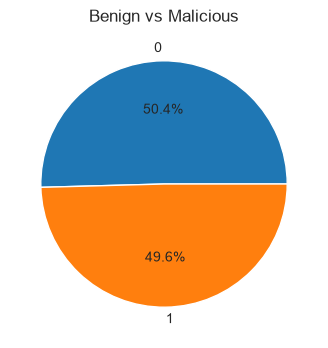

In [8]:
sns.set_style('whitegrid')
plt.figure(figsize=(6,4))
plt.pie(df['Malicious'].value_counts(), labels=df['Malicious'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign vs Malicious')
plt.show()

In [9]:
scaler=MinMaxScaler(feature_range=(0,1))
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Scaled Train Bounds: Min={x_train_scaled.min(): .1f}, Max={x_train_scaled.max(): .1f}")

Scaled Train Bounds: Min= 0.0, Max= 1.0


In [11]:
subset_train_size=200
subset_test_size=100

np.random.seed(42)
train_indices = np.random.choice(len(x_train_scaled), subset_train_size, replace=False)
test_indices = np.random.choice(len(x_test_scaled), subset_test_size, replace=False)

x_train_scaled_sub = x_train_scaled[train_indices]
x_test_scaled_sub = x_test_scaled[test_indices]

y_train_sub = y_train.iloc[train_indices]
y_test_sub = y_test.iloc[test_indices]

print(f"Downsampled DImension -> Train: {x_train_scaled_sub.shape}, Test: {x_test_scaled_sub.shape}")

Downsampled DImension -> Train: (200, 8), Test: (100, 8)


In [14]:
qX_train = x_train_scaled_sub
qX_test = x_test_scaled_sub
qy_train = y_train_sub.values
qy_test = y_test_sub.values

print(f"Dataset Dimensions -> Train: {qX_train.shape}, Test: {qX_test.shape}")

backend = AerSimulator()

num_qubits = qX_train.shape[1]
raw_feature_map = ZZFeatureMap(feature_dimension = num_qubits, reps=2, entanglement='linear')

feature_map = transpile(raw_feature_map, backend)

sampler = AerSampler.from_backend(backend)
fidelity = ComputeUncompute(sampler=sampler)

quantum_kernel = TrainableFidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

feature_map.decompose().draw()

Dataset Dimensions -> Train: (200, 8), Test: (100, 8)


/var/folders/4y/6kq8gyqj45vbmytvzf5rdm8w0000gn/T/ipykernel_12571/1552352109.py:11: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  raw_feature_map = ZZFeatureMap(feature_dimension = num_qubits, reps=2, entanglement='linear')


┌────────────┐┌───────────────┐                                       »
q_0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■────────────────────────────────────»
     ├────────────┤├───────────────┤┌─┴─┐┌────────────────────────────────┐»
q_1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,2*(π - x[0])*(π - x[1])) ├»
     ├────────────┤├───────────────┤└───┘└────────────────────────────────┘»
q_2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├───────────────────────────────────────»
     ├────────────┤├───────────────┤                                       »
q_3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├───────────────────────────────────────»
     ├────────────┤├───────────────┤                                       »
q_4: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[4]) ├───────────────────────────────────────»
     ├────────────┤├───────────────┤                                       »
q_5: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[5]) ├───────────────────────────────────────»
     ├────────────┤├───────────────┤                                       »
q_6: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[6]) ├───────────────────────────────────────»
     ├────────────┤├───────────────┤                                       »
q_7: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[7]) ├───────────────────────────────────────»
     └────────────┘└───────────────┘                                       »
«          ┌────────────┐        ┌───────────────┐                            »
«q_0: ──■──┤ U(π/2,0,π) ├────────┤ U(0,0,2*x[0]) ├────────────────────────────»
«     ┌─┴─┐└────────────┘        └───────────────┘              ┌────────────┐»
«q_1: ┤ X ├──────■───────────────────────────────────────────■──┤ U(π/2,0,π) ├»
«     └───┘    ┌─┴─┐     ┌────────────────────────────────┐┌─┴─┐└────────────┘»
«q_2: ─────────┤ X ├─────┤ U(0,0,2*(π - x[1])*(π - x[2])) ├┤ X ├──────■───────»
«              └───┘     └────────────────────────────────┘└───┘    ┌─┴─┐     »
«q_3: ──────────────────────────────────────────────────────────────┤ X ├─────»
«                                                                   └───┘     »
«q_4: ────────────────────────────────────────────────────────────────────────»
«                                                                             »
«q_5: ────────────────────────────────────────────────────────────────────────»
«                                                                             »
«q_6: ────────────────────────────────────────────────────────────────────────»
«                                                                             »
«q_7: ────────────────────────────────────────────────────────────────────────»
«                                                                             »
«                                                                              »
«q_0: ────────────────────────────────────■────────────────────────────────────»
«             ┌───────────────┐         ┌─┴─┐┌────────────────────────────────┐»
«q_1: ────────┤ U(0,0,2*x[1]) ├─────────┤ X ├┤ U(0,0,2*(π - x[0])*(π - x[1])) ├»
«             └───────────────┘         └───┘└─────────┬────────────┬─────────┘»
«q_2: ────────────────────────────────────■────────────┤ U(π/2,0,π) ├──────────»
«     ┌────────────────────────────────┐┌─┴─┐          └────────────┘          »
«q_3: ┤ U(0,0,2*(π - x[2])*(π - x[3])) ├┤ X ├────────────────■─────────────────»
«     └────────────────────────────────┘└───┘              ┌─┴─┐               »
«q_4: ─────────────────────────────────────────────────────┤ X ├───────────────»
«                                                          └───┘               »
«q_5: ─────────────────────────────────────────────────────────────────────────»
«                                                                              »
«q_6: ─────────────────────────────────────────────────────────────────────────»
«                                                                              »
«q_7: ─────────────────────────────────────────────────────────────────────────»
«                                       

In [18]:
K_train = quantum_kernel.evaluate(qX_train, qX_train)

qsvm_model=SVC(kernel='precomputed', C=1.0, random_state=42)
qsvm_model.fit(K_train, qy_train)

K_test = quantum_kernel.evaluate(qX_test, qX_train)

y_pred=qsvm_model.predict(K_test)

acc=accuracy_score(qy_test, y_pred)
auc=roc_auc_score(qy_test, y_pred)

print(f"\nAccuracy:: {acc:.4f}")
print(f"\ROC AUC:: {acc:.4f}")
print(classification_report(qy_test, y_pred, target_names=['Benign (0)', 'Malicious (1)']))

<>:14: SyntaxWarning: invalid escape sequence '\R'
<>:14: SyntaxWarning: invalid escape sequence '\R'
/var/folders/4y/6kq8gyqj45vbmytvzf5rdm8w0000gn/T/ipykernel_12571/2590427598.py:14: SyntaxWarning: invalid escape sequence '\R'
  print(f"\ROC AUC:: {acc:.4f}")



Accuracy:: 0.9800
\ROC AUC:: 0.9800
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        47
Malicious (1)       1.00      0.96      0.98        53

     accuracy                           0.98       100
    macro avg       0.98      0.98      0.98       100
 weighted avg       0.98      0.98      0.98       100



In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

model = LogisticRegression().fit(qX_train,qy_train)
confusion_matrix = metrics.confusion_matrix(qy_test,y_pred)
print(confusion_matrix)

[[47  0]
 [ 2 51]]


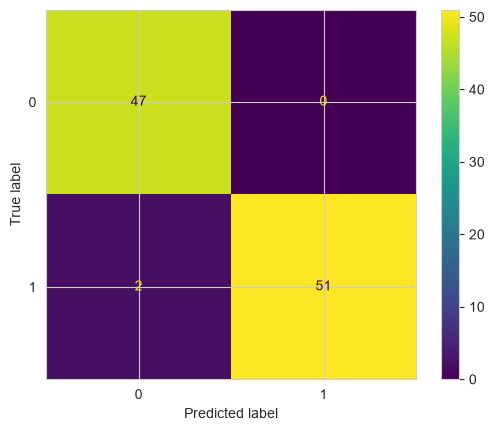

In [28]:
confusion_matrix_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
confusion_matrix_display.plot()
plt.show()